# Biochemical Oscillations

## 1. Rhythms inside cells

Many processes in living cells are not static — they pulse, cycle and oscillate. Cytosolic calcium spikes every few seconds during hormone signalling, glycolytic intermediates in yeast oscillate with a period of minutes, the cell-division cycle is itself a slow relaxation oscillator, and circadian clocks tick with a roughly 24 h period. None of these rhythms need an external pacemaker: they are generated **autonomously** by the chemical kinetics of the reaction network itself. A network that "ticks" on its own, with nothing outside it providing the beat, is a striking example of **self-organisation** in biology — temporal order emerging spontaneously from molecular interactions.

This notebook works through a minimal example of such a system: a two-variable enzyme model with *forward* and *feedback* inhibition. It is small enough to simulate, plot and analyse with standard Python (`numpy`, `scipy`, `matplotlib`, `plotly`), yet rich enough to show the core ingredients that make biochemical oscillators tick.

## 2. The recipe: feedback + delay

A simple negative feedback loop — "if X gets too high, reduce its production" — tends to settle smoothly to a steady state, the way a thermostat keeps a room at a fixed temperature. Oscillations appear when a **delay** is added to that feedback: the correction arrives too late, the system overshoots, the feedback then over-corrects in the other direction, and the cycle repeats indefinitely.

In molecular terms, delay can come from a chain of reaction steps, from a build-up to some threshold before an inhibitory step switches on, or from cooperative ("ultrasensitive") kinetics that make the response highly nonlinear. Tyson, Chen and Novak (2003) call a delayed negative-feedback loop a **"blinker"** — one of a small number of recurring dynamical motifs (*sniffers*, *buzzers*, *toggle switches* and *blinkers*) built from different combinations of positive and negative feedback in cell signalling networks.

## 3. Limit cycles and relaxation oscillators

From a mathematical perspective, a model of a robust endogenous oscillation must satisfy the following conditions:

- the equations must be dissipative, i.e. the biochemical equivalent of "friction" in mechanics. There must be losses due to "heat" production or dissipation of energy.
- the equations must be nonlinear, i.e. there must be terms of the form that we used in the creation of bistability.
- the complete model must have at least two variables. We were able to create bistability with a single equation in the case of forward inhibition but this is not sufficient for oscillation. An oscillation is a circular movement and this cannot be done in a single variable. Just like you cannot draw a circle on a line.
- And finally, in addition to the above requirements, there are specific features that then allow the "creation" of the oscillatory process. One of them is feedback inhibition. 

Mathematically, a sustained oscillation corresponds to a **limit cycle**: a closed loop in an at least two-dimensional state space. In our context, this can be the S–P plane. So we start with our bistable model and add the natural second equation for the product P of the reaction. And then we include feedback inhibition. 

The result will be an oscillator that will spontaneously create robust oscillations, And specifically, we will see the example of a **relaxation oscillator**: one variable changes slowly while it "charges up", then a second variable changes very rapidly once a threshold is crossed, "discharging" the system before the slow build-up begins again. Taken to the extreme, this can produces the characteristic spike-like or sawtooth-like time courses seen in calcium spikes, action potentials, and the repetitive cell cycle.

## 4. Why this matters in cell physiology

Oscillations are not a curiosity — cells use them to encode and process information. A classic example is intracellular calcium signalling: Woods, Cuthbertson and Cobbold (1986) showed that hormone-stimulated liver cells do not raise their calcium concentration smoothly, but instead fire **repetitive transient spikes**, with the *frequency* of spiking (rather than its amplitude) encoding the strength of the hormonal signal. Similar oscillatory strategies are used in glycolysis, in Ca2+-induced Ca2+ release, in the cell-division cycle (cyclin-CDK oscillations), and in circadian clocks. Understanding the simple dynamical mechanisms behind these rhythms — feedback, delay, nonlinearity — is therefore directly relevant to understanding how cells sense, decide and time their behaviour (Tyson, Chen & Novak, 2003; Fall et al., 2002).

## 5. What this notebook does

1. **Time series** — simulate the model for two values of the parameter `a1` and compare a steady state to an oscillation.
2. **State-space nullclines** — visualise *why* the system behaves the way it does, using nullclines, fixed points and the limit cycle.
3. **Oscillation animation** — an intuitive picture of S and P oscillating out of phase.
4. **Bifurcation analysis** — using the companion script `enzym_oscillations_bifurcation.py`, systematically scan `a1` to map out exactly where oscillations occur.
5. **Summary and further reading** — what the simulations tell us, and where to learn more.


In [1]:
from scipy.integrate import solve_ivp
from matplotlib.pyplot import subplots
import numpy as np


# Forward inhibition combined with feedback inhibition

## The model

The model tracks two state variables, a "substrate" $S$ and a "product" $P$ — think of them as the concentrations of two interconverting metabolites:

$$\frac{dS}{dt} = a_1 - b_1 S - v(S, P)$$
$$\frac{dP}{dt} = a_2 - b_2 P + v(S, P)$$

with the enzymatic conversion rate

$$v(S, P) = \frac{k_{max}\, S^{\,n}}{K_m^{\,m} + S^{\,m}} \cdot \frac{1}{1 + k_i\, P^{\,q}}$$

Reading the equations biologically:

- $a_1$ and $a_2$ — constant **production** ("inflow") rates of $S$ and $P$.
- $b_1$ and $b_2$ — first-order **removal** ("outflow") rates, e.g. dilution or degradation.
- $v(S,P)$ — the rate at which an enzyme converts $S$ into $P$. The same flux leaves $S$ and arrives in $P$, so this term appears with opposite signs in the two equations.
  - $\dfrac{S^{\,n}}{K_m^{\,m} + S^{\,m}}$ — **forward dependence on $S$**: the enzyme needs substrate to work, and its rate saturates once $S$ is large (Hill-type/Michaelis–Menten-like kinetics).
  - $\dfrac{1}{1 + k_i P^{\,q}}$ — **feedback inhibition**: the product $P$ inhibits the enzyme that produces it. This is the *delayed negative feedback* from the introduction — $P$ must accumulate before it can shut down its own production.

The exponents $n$, $m$ and $q$ control how sharply (how "switch-like") $S$ activates, and $P$ inhibits, the enzyme. Throughout this notebook, $a_1$ — the supply rate of $S$ — is the parameter we vary; it acts as the main control knob (the **bifurcation parameter**) that switches the system between a stable steady state and sustained oscillations.


## Time Series

We start with the most direct test: simulate the ODEs over time for two values of $a_1$ and look at the trajectories of $S(t)$ and $P(t)$.

- For one value of $a_1$, the system should settle down to a constant **steady state**.
- For the other value, $S$ and $P$ should **oscillate indefinitely**, out of phase with each other.

The right-hand panels below show the same trajectories in the $S$–$P$ plane (the "phase plane" or "state space"): a steady state appears as a single point, while an oscillation appears as a closed loop.


In [2]:
def model(t, variables, a1, b1, a2, b2, k_max, K_m, k_i, n, m, q):
    """
    Right-hand side of the ODE system: returns [dS/dt, dP/dt].

    `variables` packs the two state variables (S, P) into a single
    list, as required by `solve_ivp`. The remaining arguments are the
    fixed model parameters (rate constants and Hill exponents).
    """
    S, P = variables

    # Rate of the enzyme reaction that converts S -> P.
    #  - S**n / (K_m**m + S**m): forward dependence on S - saturating,
    #    Hill-type kinetics (more substrate -> faster reaction, up to a limit)
    #  - 1 / (1 + k_i * P**q): feedback inhibition - more product P
    #    slows the reaction down (delayed negative feedback)
    enzymatic_rate = (k_max * S**n) / (K_m + S**m) / (1 + k_i * P**q)

    # S is produced at constant rate a1, removed by first-order decay
    # (b1*S), and consumed by the enzyme reaction.
    dSdt = a1 - b1 * S - enzymatic_rate

    # P is produced at constant rate a2, removed by first-order decay
    # (b2*P), and produced by the enzyme reaction - the flux that
    # leaves S arrives in P, so the same term appears with a + sign here.
    dPdt = a2 - b2 * P + enzymatic_rate

    return [dSdt, dPdt]


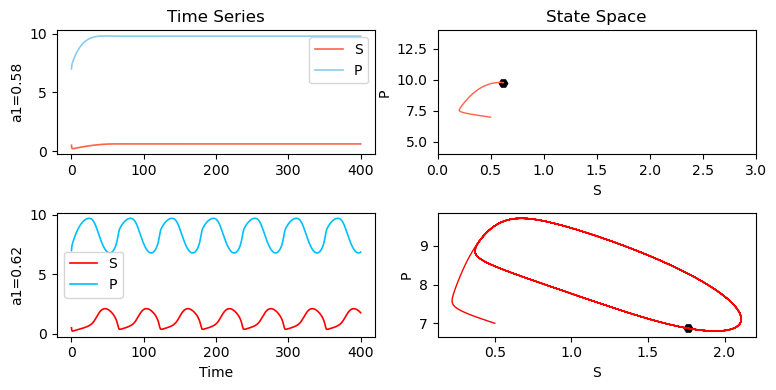

In [3]:
# Initial concentrations [S(0), P(0)] - same starting point for both runs below
y0 = [0.5, 7]

# We run the SAME model twice, changing only a1 (the supply rate of S).
# a1 is the parameter that determines whether the system settles to a
# steady state or oscillates - see the Bifurcation analysis section later.
a1 = [0.58, 0.62]   # a1[0] -> steady state, a1[1] -> sustained oscillation

# Fixed parameters, kept the same for both runs
a2      = 0.02
b1, b2  = 0.18, 0.05

k_max, K_m, k_i = 25.0, 0.34, 0.06
n, m, q = 1, 3, 3

# Time interval to integrate over
t_span = (0, 400)

colors = [('tomato', 'skyblue'), ('red', 'deepskyblue')]

# Layout: one row per a1 value (steady state / oscillation),
# left column = concentrations vs time, right column = phase plane (S vs P)
fig, ax = subplots(ncols=2, nrows=2, figsize=(8, 4))

for index, color in enumerate(colors):

    # Numerically integrate the ODEs with solve_ivp.
    #  - method='BDF': an implicit solver well suited to "stiff" systems,
    #    where some variables change much faster than others (common in
    #    biochemical models with very different rate constants).
    #  - max_step=0.1: forces small time steps so that fast transients
    #    (e.g. the rapid part of a relaxation oscillation) are not missed.
    solution = solve_ivp(model, t_span, y0, args=(a1[index], b1, a2, b2, k_max, K_m, k_i, n, m, q,), method='BDF', max_step=0.1)

    t = solution.t

    S = solution.y[0]
    P = solution.y[1]


    # Left column: concentrations of S and P over time
    ax[index, 0].plot(t, S, label='S', linewidth=1.2, color=colors[index][0])
    ax[index, 0].plot(t, P, label='P', linewidth=1.2, color=colors[index][1])
    # Right column: phase-plane trajectory (S vs P); the marker shows
    # where the trajectory ends up at t = t_span[1]
    ax[index, 1].scatter(S[-1], P[-1], c='k', marker='H')
    ax[index, 1].plot(S, P, linewidth=1, color=colors[index][0]);
    ax[index, 0].set_ylabel(f'a1={a1[index]}')


ax[1, 0].set_xlabel('Time')
ax[0, 0].legend()
ax[0, 0].set_title('Time Series')
ax[1, 0].legend()

ax[0, 1].set_xlabel('S')
ax[1, 1].set_xlabel('S')
ax[0, 1].set_ylabel('P')
ax[1, 1].set_ylabel('P')
ax[0, 1].set_title('State Space')
ax[0, 1].set_xlim(0, 3)
ax[0, 1].set_ylim(4, 14)


fig.tight_layout()

In [4]:
# Final (S, P) values reached at t = 700 for the SECOND run above (a1 = 0.62),
# rounded to 2 decimals for readability.
# If that run is oscillating, this is just a snapshot at one point in time -
# NOT a fixed point - the system keeps moving after this.
np.around((S[-1], P[-1]), 2)

array([1.76, 6.87])

The oscillation can be said to "break symmetry in time".

## State Space Nullclines

The time series tell us *what* happens, but not *why*. To understand why the system oscillates for some parameter values and not others, it helps to look at the phase plane more carefully, using two classic tools from dynamical systems theory:

- A **nullcline** is the set of points where one variable's rate of change is zero. The $S$-nullcline is where $dS/dt = 0$; the $P$-nullcline is where $dP/dt = 0$.
- A **fixed point** (steady state) is a point where *both* rates of change are zero at once — i.e. where the two nullclines intersect.

If the fixed point is **stable**, nearby trajectories spiral *into* it (this matches the steady-state behaviour seen above for one value of $a_1$). If it is **unstable**, nearby trajectories spiral *away* from it — but they cannot run off to infinity, so instead they settle onto a surrounding closed loop: the **limit cycle** corresponding to the oscillation.

The cell below computes both nullclines numerically (root-finding with `fsolve`), locates the fixed point, and overlays a simulated trajectory to reveal the limit cycle directly.


NULLCLINE ANALYSIS FOR OSCILLATORY SYSTEM
b1=0.18, b2=0.05
a1=0.65, a2=0.02
k_max=25.0, K_m=0.34
k_i=0.06
n=1, m=3, q=3

Computing S-nullcline...
Computing P-nullcline...
Finding fixed points...
Found 1 fixed point(s):
  FP1: S = 1.729, P = 7.174
Adding limit cycle from simulation...


/var/folders/cs/lkcj7j890kv6kfxbkl56w9h80000gn/T/ipykernel_14359/643221944.py:139: RuntimeWarning:

The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.



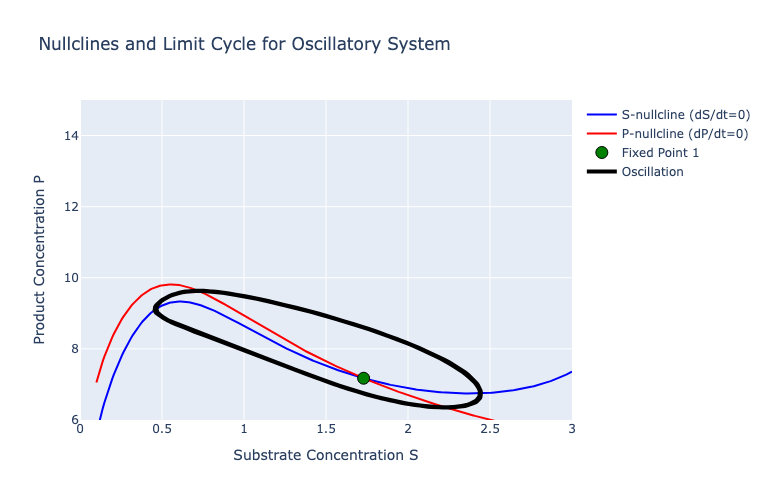


MATHEMATICAL ANALYSIS
Nullcline equations:
S-nullcline: a₁ - b₁·S = k_max·S/(K_m + S³) · 1/(1 + k_i·P²)
P-nullcline: a₂ - b₂·P = -k_max·S/(K_m + S³) · 1/(1 + k_i·P²)

Rearranged:
S-nullcline: P = √[(k_max·S/((a₁ - b₁·S)(K_m + S³)) - 1)/k_i]
P-nullcline: P = [a₂ + k_max·S/((K_m + S³)(1 + k_i·P²))]/b₂

Single fixed point at: S = 1.729, P = 7.174
This is typical for oscillatory systems - an unstable fixed point
surrounded by a stable limit cycle!
Fixed point appears STABLE

The purple limit cycle shows sustained oscillations around the fixed point!


In [5]:
import plotly.graph_objects as go
from scipy.optimize import fsolve

# Oscillatory parameters - we fix a1 at a single value for this analysis
# (one of the parameter sets that produces sustained oscillations;
# compare with the bifurcation analysis later in the notebook)
a1_fixed = 0.65

print("NULLCLINE ANALYSIS FOR OSCILLATORY SYSTEM")
print("="*50)
print(f"b1={b1}, b2={b2}")
print(f"a1={a1_fixed}, a2={a2}")
print(f"k_max={k_max}, K_m={K_m}")
print(f"k_i={k_i}")
print(f"n={n}, m={m}, q={q}")
print()

def enzymatic_rate(S, P):
    """Enzymatic rate with forward and feedback inhibition"""
    return (k_max * S**n) / (K_m + S**m) / (1 + k_i * P**q)

def S_nullcline(S, P):
    """S-nullcline: dS/dt = 0 => a1 - b1*S = v(S,P)"""
    return a1_fixed - b1*S - enzymatic_rate(S, P)

def P_nullcline(S, P):
    """P-nullcline: dP/dt = 0 => a2 - b2*P = -v(S,P)"""
    return a2       - b2*P + enzymatic_rate(S, P)

# --- S-nullcline ---------------------------------------------------------
# For each value of S, find the value(s) of P that satisfy dS/dt = 0.
# This is a 1D root-finding problem (in P) for each fixed S, solved with
# fsolve. We try several starting guesses for P because the equation can
# have more than one solution (the nullcline can be multi-valued in P).
print("Computing S-nullcline...")
S_values = np.linspace(0.1, 3, 300)
P_S_null = []

for S in S_values:
    def equation(P):
        return S_nullcline(S, P)

    try:
        # Try multiple initial guesses
        solutions = []
        for P_guess in [5.0, 6.0, 7.0, 8.0]:
            result = fsolve(equation, P_guess)
            if (result[0] > 0 and result[0] < 15 and
                abs(equation(result[0])) < 1e-6):
                solutions.append(result[0])

        # Remove duplicates and take the first valid solution
        if solutions:
            unique_solutions = []
            for sol in solutions:
                if not any(abs(sol - existing) < 0.1 for existing in unique_solutions):
                    unique_solutions.append(sol)
            P_S_null.append(unique_solutions[0])  # Take first branch for plotting
        else:
            P_S_null.append(np.nan)
    except:
        P_S_null.append(np.nan)

# --- P-nullcline ----------------------------------------------------------
# Same idea as above, but now solving dP/dt = 0 for P at each fixed S.
print("Computing P-nullcline...")
P_P_null = []

for S in S_values:
    def equation(P):
        return P_nullcline(S, P)

    try:
        # Try multiple initial guesses
        solutions = []
        for P_guess in [0.1, 1.0, 3.0, 5.0]:
            result = fsolve(equation, P_guess)
            if (result[0] > 0 and result[0] < 15 and
                abs(equation(result[0])) < 1e-6):
                solutions.append(result[0])

        # Remove duplicates and take the first valid solution
        if solutions:
            unique_solutions = []
            for sol in solutions:
                if not any(abs(sol - existing) < 0.1 for existing in unique_solutions):
                    unique_solutions.append(sol)
            P_P_null.append(unique_solutions[0])  # Take first branch for plotting
        else:
            P_P_null.append(np.nan)
    except:
        P_P_null.append(np.nan)

# --- Plot the phase portrait ----------------------------------------------
fig = go.Figure()

# Plot S-nullcline
valid_S_S = []
valid_P_S = []
for S, P in zip(S_values, P_S_null):
    if not np.isnan(P):
        valid_S_S.append(S)
        valid_P_S.append(P)

fig.add_trace(go.Scatter(x=valid_S_S, y=valid_P_S, mode='lines',
                        name='S-nullcline (dS/dt=0)',
                        line=dict(color='blue', width=2)))

# Plot P-nullcline
valid_S_P = []
valid_P_P = []
for S, P in zip(S_values, P_P_null):
    if not np.isnan(P):
        valid_S_P.append(S)
        valid_P_P.append(P)

fig.add_trace(go.Scatter(x=valid_S_P, y=valid_P_P, mode='lines',
                        name='P-nullcline (dP/dt=0)',
                        line=dict(color='red', width=2)))

# --- Fixed point(s): where BOTH nullclines are satisfied simultaneously ---
# Search on a grid of (S, P) starting guesses and solve the 2x2 system
# [S_nullcline, P_nullcline] = [0, 0] with fsolve from each starting point.
# Duplicate solutions (within 0.1 of an existing one) are discarded.
print("Finding fixed points...")
fixed_points = []

# Search in S-P space
S_search = np.linspace(0.01, 1.2, 50)
P_search = np.linspace(9, 11, 50)

for S_guess in S_search:
    for P_guess in P_search:
        def equations(vars):
            S, P = vars
            return [S_nullcline(S, P), P_nullcline(S, P)]

        try:
            result = fsolve(equations, [S_guess, P_guess])
            S_sol, P_sol = result

            # Check if valid solution
            residuals = equations([S_sol, P_sol])
            if (np.linalg.norm(residuals) < 1e-4 and
                S_sol > 0 and P_sol > 0 and
                S_sol <= 2 and P_sol <= 15):

                # Check if new
                is_new = True
                for existing in fixed_points:
                    if (abs(S_sol - existing[0]) < 0.1 and
                        abs(P_sol - existing[1]) < 0.1):
                        is_new = False
                        break

                if is_new:
                    fixed_points.append((S_sol, P_sol))
        except:
            continue

print(f"Found {len(fixed_points)} fixed point(s):")
for i, (S, P) in enumerate(fixed_points):
    print(f"  FP{i+1}: S = {S:.3f}, P = {P:.3f}")

# Plot fixed points
for i, (S, P) in enumerate(fixed_points):
    fig.add_trace(go.Scatter(x=[S], y=[P], mode='markers',
                            marker=dict(size=12, color='green', symbol='circle',
                                      line=dict(width=1, color='black')),
                            name=f'Fixed Point {i+1}'))

# --- Limit cycle: simulate from an arbitrary starting point and discard ---
# the initial transient. If the fixed point is unstable, the trajectory
# will converge onto the surrounding limit cycle.
print("Adding limit cycle from simulation...")
from scipy.integrate import solve_ivp

def system_dynamics(t, variables):
    S, P = variables
    rate = enzymatic_rate(S, P)
    dSdt = a1_fixed - b1*S - rate
    dPdt = a2       - b2*P + rate
    return [dSdt, dPdt]

# Simulate to get limit cycle
sol = solve_ivp(system_dynamics, (0, 2000), [1.0, 1.0],
                t_eval=np.linspace(0, 2000, 5000), method='RK45')

# Use only the last part to avoid transients
S_cycle = sol.y[0][-2000:]
P_cycle = sol.y[1][-2000:]

fig.add_trace(go.Scatter(x=S_cycle, y=P_cycle, mode='lines',
                        name='Oscillation',
                        line=dict(color='black', width=4)))

# Update layout
fig.update_layout(
    title="Nullclines and Limit Cycle for Oscillatory System",
    xaxis_title="Substrate Concentration S",
    yaxis_title="Product Concentration P",
    width=600,
    height=500,
    showlegend=True
)

fig.update_xaxes(range=[0, 3])
fig.update_yaxes(range=[6, 15])

fig.show()

# --- Mathematical summary --------------------------------------------------
print("\n" + "="*50)
print("MATHEMATICAL ANALYSIS")
print("="*50)

print("Nullcline equations:")
print("S-nullcline: a₁ - b₁·S = k_max·S/(K_m + S³) · 1/(1 + k_i·P²)")
print("P-nullcline: a₂ - b₂·P = -k_max·S/(K_m + S³) · 1/(1 + k_i·P²)")
print()
print("Rearranged:")
print("S-nullcline: P = √[(k_max·S/((a₁ - b₁·S)(K_m + S³)) - 1)/k_i]")
print("P-nullcline: P = [a₂ + k_max·S/((K_m + S³)(1 + k_i·P²))]/b₂")
print()

# A single fixed point that is unstable, together with a bounded phase
# plane, implies (by the Poincare-Bendixson theorem) that trajectories
# must converge onto a periodic orbit - the limit cycle plotted above.
if len(fixed_points) == 1:
    S_fp, P_fp = fixed_points[0]
    print(f"Single fixed point at: S = {S_fp:.3f}, P = {P_fp:.3f}")
    print("This is typical for oscillatory systems - an unstable fixed point")
    print("surrounded by a stable limit cycle!")

    # Check stability roughly by simulating nearby
    sol_test = solve_ivp(system_dynamics, (0, 50), [S_fp + 0.1, P_fp + 0.1],
                        t_eval=[0, 50], method='RK45')
    final_S, final_P = sol_test.y[0, -1], sol_test.y[1, -1]
    distance = np.sqrt((final_S - S_fp)**2 + (final_P - P_fp)**2)

    if distance > 0.5:
        print("Fixed point appears UNSTABLE (spiral source)")
    else:
        print("Fixed point appears STABLE")

print("\nThe purple limit cycle shows sustained oscillations around the fixed point!")

## Oscillation animation

Numbers and curves can feel abstract — this final visualisation turns the oscillation into something more intuitive. Two circles represent the concentrations of $S$ and $P$: as each concentration rises and falls over time, its circle grows and shrinks. Because $S$ is consumed to produce $P$ (and $P$ feeds back to inhibit that conversion), the two circles pulse **out of phase** — as $S$ grows, $P$ shrinks, and vice versa. This alternating "charge / discharge" pattern is the visual signature of the relaxation oscillator described in the introduction.

Use the **Play** button (or drag the time slider) to watch the oscillation unfold.


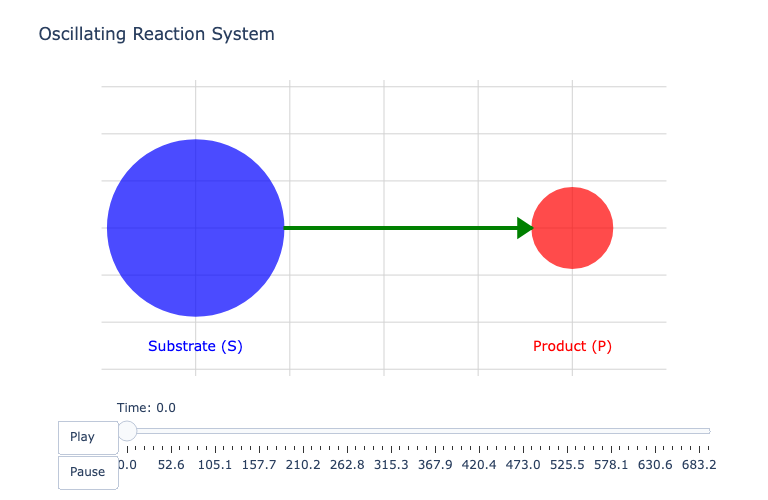

In [6]:
import plotly.graph_objects as go

# ---------------------------------------------------------------------------
# This cell re-simulates the model for a1 = 0.62 (the oscillatory case from
# the Time Series section above) and then builds an animated plotly figure:
#  - one circle for S, one circle for P, whose RADII are rescaled versions
#    of their concentrations over time
#  - a green arrow representing the "flow" from S to P
#  - a time slider and Play/Pause buttons to step through the simulation
# Most of the code below is plotly bookkeeping (shapes, frames, layout);
# the parts that matter biologically are the model/parameters at the top
# and the radius normalisation just below the simulation.
# ---------------------------------------------------------------------------

# Model definition (identical to the `model` function used earlier)
def model(t, variables, a1, b1, a2, b2, k_max, K_m, k_i, n, m, q):
    """Coupled system with feedback inhibition"""
    S, P = variables
    
    enzymatic_rate = (k_max * S**n) / (K_m + S**m) / (1 + k_i * P**q)
    
    dSdt = a1 - b1 * S - enzymatic_rate
    dPdt = a2 - b2 * P + enzymatic_rate
    
    return [dSdt, dPdt]

S_0 = 1.97
P_0 = 6.97

# Parameters
a1, a2 = 0.62, 0.02
b1, b2 = 0.18, 0.05

k_max, K_m, k_i = 25.0, 0.34, 0.06
n, m, q = 1, 3, 3

t_span = (0, 700)

# Solve the ODE for a1 = 0.62 (oscillatory case)
t_eval = np.linspace(t_span[0], t_span[1], 1000)  # Even fewer points for stability
sol = solve_ivp(model, t_span, [S_0, P_0], args=(a1, b1, a2, b2, k_max, K_m, k_i, n, m, q), 
                t_eval=t_eval, method='RK45')

S_sol = sol.y[0]
P_sol = sol.y[1]
t_sol = sol.t

# Rescale S and P to a fixed radius range [min_radius, max_radius],
# so each species is drawn as a circle that visibly grows/shrinks
# over the course of the oscillation, regardless of its absolute
# concentration units.
# Normalize for circle radii - using pixel units for shapes
min_radius, max_radius = 15, 40
S_radius = min_radius + (max_radius - min_radius) * (S_sol - np.min(S_sol)) / (np.max(S_sol) - np.min(S_sol))
P_radius = min_radius + (max_radius - min_radius) * (P_sol - np.min(P_sol)) / (np.max(P_sol) - np.min(P_sol))

# Fixed positions
S_pos = [-4, 0]
P_pos = [4, 0]

# Build the animation: one "frame" per simulated time point, each
# redrawing the S and P circles (and the connecting arrow) at the
# size corresponding to that time point's concentrations.
# Create the figure with shapes (much more stable than scatter plots)
fig = go.Figure()

# Create frames using shapes instead of scatter plots
frames = []
for i in range(len(t_sol)):
    frame_data = [
        # S circle as shape
        dict(
            type="circle",
            xref="x", yref="y",
            x0=S_pos[0] - S_radius[i]/20,  # Divide by scaling factor
            y0=S_pos[1] - S_radius[i]/20,
            x1=S_pos[0] + S_radius[i]/20,
            y1=S_pos[1] + S_radius[i]/20,
            line_color="blue",
            fillcolor="blue",
            line_width=2,
            opacity=0.7
        ),
        # P circle as shape
        dict(
            type="circle",
            xref="x", yref="y",
            x0=P_pos[0] - P_radius[i]/20,
            y0=P_pos[1] - P_radius[i]/20,
            x1=P_pos[0] + P_radius[i]/20,
            y1=P_pos[1] + P_radius[i]/20,
            line_color="red",
            fillcolor="red",
            line_width=2,
            opacity=0.7
        ),
        # Arrow line
        dict(
            type="line",
            xref="x", yref="y",
            x0=S_pos[0] + S_radius[i]/20,
            y0=S_pos[1],
            x1=P_pos[0] - P_radius[i]/20,
            y1=P_pos[1],
            line=dict(color="green", width=4)
        ),
        # Arrow head
        dict(
            type="path",
            xref="x", yref="y",
            path=f"M {P_pos[0] - P_radius[i]/20 - 0.3} {P_pos[1] - 0.2} L {P_pos[0] - P_radius[i]/20} {P_pos[1]} L {P_pos[0] - P_radius[i]/20 - 0.3} {P_pos[1] + 0.2} Z",
            line_color="green",
            fillcolor="green"
        )
    ]

    frame = go.Frame(
        data=[],  # No scatter data
        layout=dict(
            shapes=frame_data,
            # annotations=text_annotations
        ),
        name=f'frame_{i}'
    )
    frames.append(frame)

# Add initial shapes
fig.add_shape(
    type="circle",
    xref="x", yref="y",
    x0=S_pos[0] - S_radius[0]/20,
    y0=S_pos[1] - S_radius[0]/20,
    x1=S_pos[0] + S_radius[0]/20,
    y1=S_pos[1] + S_radius[0]/20,
    line_color="blue",
    fillcolor="blue",
    line_width=2,
    opacity=0.7
)

fig.add_shape(
    type="circle",
    xref="x", yref="y",
    x0=P_pos[0] - P_radius[0]/20,
    y0=P_pos[1] - P_radius[0]/20,
    x1=P_pos[0] + P_radius[0]/20,
    y1=P_pos[1] + P_radius[0]/20,
    line_color="red",
    fillcolor="red", 
    line_width=2,
    opacity=0.7
)

fig.add_shape(
    type="line",
    xref="x", yref="y",
    x0=S_pos[0] + S_radius[0]/20,
    y0=S_pos[1],
    x1=P_pos[0] - P_radius[0]/20,
    y1=P_pos[1],
    line=dict(color="green", width=4)
)

fig.add_shape(
    type="path",
    xref="x", yref="y",
    path=f"M {P_pos[0] - P_radius[0]/20 - 0.3} {P_pos[1] - 0.2} L {P_pos[0] - P_radius[0]/20} {P_pos[1]} L {P_pos[0] - P_radius[0]/20 - 0.3} {P_pos[1] + 0.2} Z",
    line_color="green",
    fillcolor="green"
)

# Add initial annotations
fig.add_annotation(
    x=S_pos[0],
    y=S_pos[1] - max(S_radius[0], P_radius[0])/15 - 0.8,
    # text=f"S: {S_sol[0]:.2f}",
    showarrow=False,
    font=dict(color="blue", size=12),
    xref="x",
    yref="y"
)

fig.add_annotation(
    x=P_pos[0],
    y=P_pos[1] - max(S_radius[0], P_radius[0])/15 - 0.8,
    # text=f"P: {P_sol[0]:.2f}",
    showarrow=False,
    font=dict(color="red", size=12),
    xref="x",
    yref="y"
)

# Configure animation
fig.frames = frames

# Animation controls: a time slider plus Play/Pause buttons
sliders = [dict(
    steps=[dict(
        method="animate",
        args=[[f'frame_{k}'], 
              dict(mode="immediate", frame=dict(duration=50, redraw=True), 
                   transition=dict(duration=0))],
        label=f'{t_sol[k]:.1f}'
    ) for k in range(0, len(t_sol), 15)],
    active=0,
    currentvalue=dict(prefix="Time: ", visible=True),
    len=0.9,
    x=0.1,
    y=0
)]

updatemenus = [dict(
    type="buttons",
    showactive=False,
    buttons=[
        dict(label="Play", method="animate",
             args=[None, dict(frame=dict(duration=50, redraw=True), 
                             fromcurrent=True, mode="immediate")]),
        dict(label="Pause", method="animate",
             args=[[None], dict(frame=dict(duration=0, redraw=False), 
                               mode="immediate")])
    ],
    x=0.1, y=-0.15,
    xanchor="right",
    yanchor="top"
)]

# Update layout with FIXED ranges and no auto-scaling
fig.update_layout(
    title="Oscillating Reaction System",
    xaxis=dict(
        range=[-6, 6],  # Fixed range
        showticklabels=False,
        showgrid=True,
        gridcolor="lightgray",
        zeroline=False,
        fixedrange=True,  # Prevent any scaling
        constrain="domain"
    ),
    yaxis=dict(
        range=[-3, 3],  # Fixed range
        showticklabels=False,
        showgrid=True,
        gridcolor="lightgray",
        zeroline=False,
        fixedrange=True,  # Prevent any scaling
        scaleanchor="x",
        scaleratio=1
    ),
    plot_bgcolor="white",
    width=800,
    height=500,
    showlegend=False,
    sliders=sliders,
    updatemenus=updatemenus,
    # Critical: disable all auto-scaling and layout recalculations
    autosize=False,
    margin=dict(l=50, r=50, t=80, b=80)
)

# Add static labels
fig.add_annotation(
    x=S_pos[0], y=-2.5,
    text="Substrate (S)",
    showarrow=False,
    font=dict(color="blue", size=14),
    xref="x",
    yref="y"
)

fig.add_annotation(
    x=P_pos[0], y=-2.5,
    text="Product (P)",
    showarrow=False,
    font=dict(color="red", size=14),
    xref="x", 
    yref="y"
)

fig.show()

# Summary: what can we learn from these simulations?

**A handful of ingredients is enough to oscillate.** The model has only two state variables ($S$, $P$) and a small number of parameters, yet it can settle to a steady state *or* oscillate indefinitely, purely as a consequence of its chemical kinetics — no external clock or rhythmic input is needed. This is the essence of self-organised behaviour in biochemical networks.

**The nullclines explain the mechanism.** Forward dependence on $S$ together with feedback inhibition by $P$ shapes the nullclines so that, for some parameter values, they intersect at a single, *unstable* fixed point. Because trajectories cannot escape to infinity (concentrations stay bounded), an unstable fixed point in a bounded 2D phase plane forces trajectories onto a surrounding closed orbit — the limit cycle we see as a sustained oscillation.

**$a_1$ acts as a switch between dynamical regimes.** The bifurcation analysis shows that oscillations occur only within a *finite window* of $a_1$, bounded by two Hopf bifurcations. Outside this window the system is at a stable steady state; inside it, the system oscillates, with the amplitude growing from zero near each bifurcation point. Biologically, $a_1$ represents a supply rate — so a cell could move into or out of an oscillatory regime simply by up- or down-regulating the production of $S$ (e.g. via an upstream signalling pathway), without needing to rebuild the whole network.

**The animation makes the relaxation-oscillator pattern visible.** $S$ and $P$ rise and fall out of phase, with periods of slow change punctuated by faster swings — the qualitative pattern shared by many real biological oscillators (e.g. the calcium spikes of Woods et al., 1986).

**This is a minimal example of a recurring motif.** The combination of production, removal, and delayed negative feedback recurs throughout cell biology, in systems that look very different at the molecular level: calcium signalling, glycolytic oscillations, the cyclin-CDK cell-cycle oscillator, and circadian clocks (Tyson, Chen & Novak, 2003; Fall et al., 2002). Recognising this shared "dynamical vocabulary" — feedback loops, nullclines, fixed points, bifurcations, limit cycles — is often more useful for understanding *why* a system behaves as it does than memorising the specific molecular players.

### Ideas for further exploration

- Change `k_i`, `K_m`, `n`, `m` or `q` in the Time Series cell and re-run — how does the oscillatory window (found via the bifurcation script) shift?
- Pick an $a_1$ value just outside the oscillatory window and run the nullcline cell — how do the nullclines and fixed point change compared with $a_1 = 0.65$?
- Try a longer or shorter `t_span` in the Time Series cell for an oscillatory $a_1$ — how many cycles does it take to reach the limit cycle from the initial condition?
- Modify the bifurcation script to scan a *different* parameter (e.g. `k_i`) instead of `a1`, holding `a1` fixed — does the same qualitative picture (a finite oscillatory window) appear?


# References and further reading

## Papers and book provided with this notebook

- Woods, N.M., Cuthbertson, K.S.R. & Cobbold, P.H. (1986). *Repetitive transient rises in cytoplasmic free calcium in hormone-stimulated hepatocytes.* Nature 319, 600-602. (`CalciumOscillations Woods1986.pdf`) — the classic experimental demonstration that hormone signalling produces repetitive calcium *spikes* rather than a sustained rise, with frequency encoding signal strength. A great example of why the kind of dynamics studied in this notebook matters physiologically.

- Tyson, J.J., Chen, K.C. & Novak, B. (2003). *Sniffers, buzzers, toggles and blinkers: dynamics of regulatory and signaling pathways in the cell.* Current Opinion in Cell Biology 15, 221-231. (`Sniffers Tyson2003.pdf`) — a short, readable review introducing the "dynamical vocabulary" (feedback, switches, oscillators) used throughout this notebook, with many biological examples.

- Fall, C.P., Marland, E.S., Wagner, J.M. & Tyson, J.J. (eds.) (2002). *Computational Cell Biology.* Springer (Interdisciplinary Applied Mathematics, vol. 20). (`Computational Cell Biology FallTyson2000.pdf`) — a textbook aimed at biology and mathematics students together. Chapter 2 (on voltage-gated ionic currents and the Morris-Lecar model) contains an especially clear, general discussion of *why* oscillations occur in dynamical systems, including nullclines, stability and the Poincare-Bendixson argument used informally above.

## Beginner-friendly further reading (not included as files)

- Strogatz, S.H. *Nonlinear Dynamics and Chaos* (2nd ed., 2015), Westview Press. The standard, very accessible introduction to phase planes, nullclines, fixed points, limit cycles and bifurcations — written for readers without a strong mathematics background.

- Novak, B. & Tyson, J.J. (2008). *Design principles of biochemical oscillators.* Nature Reviews Molecular Cell Biology 9, 981-991. A review connecting the simple oscillator "design principles" introduced here to real cell-cycle and circadian oscillators.

- Ferrell, J.E., Tsai, T.Y.-C. & Yang, Q. (2011). *Modeling the cell cycle: why do certain circuits oscillate?* Cell 144, 874-885. A particularly approachable explanation of how feedback and delay combine to produce oscillations, using the cell cycle as the running example.

- Goldbeter, A. *Biochemical Oscillations and Cellular Rhythms* (1996), Cambridge University Press. A comprehensive but accessible survey of biological oscillators, from glycolysis to circadian rhythms, by one of the field's pioneers.
